In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/achilov15/french-review-labeled/french_labeled.csv


## Business Insights from Restaurant Reviews

This is the first stage of business insights extraction from restaurant reviews. After our ABSA model analyzed all customer reviews and identified aspects together with their associated sentiment, we can begin identifying the restaurant's key strengths and weaknesses. These insights help uncover recurring customer concerns and highlight areas where operational improvements can have the greatest impact.

In [10]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/achilov15/french-review-labeled/french_labeled.csv")
analysis_df = df.copy()

## Data Quality Verification

Before drawing any business conclusions, it is important to verify that the processed data is reliable and consistent. This step ensures that the extracted aspects and sentiment labels are suitable for further analysis and that the resulting business insights are based on high-quality data.

<Axes: xlabel='stars', ylabel='Count'>

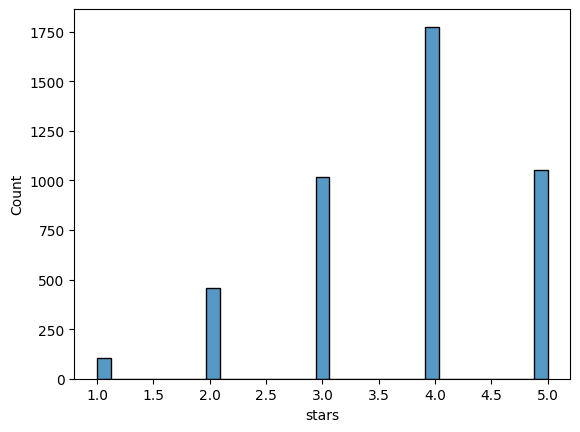

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt


sns.histplot(x = "stars", data= df)

In [12]:
df.head()

,id,text,stars,aspect,polarity,proba_predicted_label,confidence,proba_conflict,proba_negative,proba_neutral,...,llm_reason,final_aspect,final_polarity,human_checked,corrected_aspect,corrected_polarity,keep,comment,threshold,timestamp
0,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,Saturday w/ friends,positive,positive,0.952047,0.007945,0.010735,0.029272,...,NaN,Saturday w/ friends,positive,False,Saturday w/ friends,positive,1,NaN,0.6,2026-07-13 17:44:48.983523
1,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,Half,positive,positive,0.946624,0.008993,0.012698,0.031684,...,NaN,Half,positive,False,Half,positive,1,NaN,0.6,2026-07-13 17:44:48.983535
2,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,hour,positive,positive,0.954948,0.007601,0.010260,0.027191,...,NaN,hour,positive,False,hour,positive,1,NaN,0.6,2026-07-13 17:44:48.983541
3,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,shelf liqueur,positive,positive,0.958315,0.007327,0.009825,0.024534,...,NaN,shelf liqueur,positive,False,shelf liqueur,positive,1,NaN,0.6,2026-07-13 17:44:48.983547
4,0,Came Saturday w/ friends at 11:30am. Half off ...,5.0,Mary EVER,positive,positive,0.958103,0.007185,0.009819,0.024893,...,NaN,Mary EVER,positive,False,Mary EVER,positive,1,NaN,0.6,2026-07-13 17:44:48.983552


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4406 non-null   int64  
 1   text                   4406 non-null   object 
 2   stars                  4406 non-null   float64
 3   aspect                 4406 non-null   object 
 4   polarity               4406 non-null   object 
 5   proba_predicted_label  4406 non-null   object 
 6   confidence             4406 non-null   float64
 7   proba_conflict         4406 non-null   float64
 8   proba_negative         4406 non-null   float64
 9   proba_neutral          4406 non-null   float64
 10  proba_positive         4406 non-null   float64
 11  llm_called             4406 non-null   bool   
 12  llm_raw_response       699 non-null    object 
 13  llm_aspect             699 non-null    object 
 14  llm_polarity           699 non-null    object 
 15  llm_

In [14]:
df.describe()

,id,stars,confidence,proba_conflict,proba_negative,proba_neutral,proba_positive,keep,threshold
count,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.0,4.406000e+03
mean,97.279619,3.729006,0.817638,0.031322,0.138453,0.104927,0.725297,1.0,6.000000e-01
std,56.711320,1.012569,0.204275,0.033711,0.214067,0.122056,0.353424,0.0,4.941053e-14
min,0.000000,1.000000,0.300518,0.004768,0.005258,0.013162,0.029092,1.0,6.000000e-01
25%,47.000000,3.000000,0.635295,0.007270,0.008449,0.023205,0.399709,1.0,6.000000e-01
50%,97.000000,4.000000,0.941507,0.011219,0.013529,0.034182,0.941507,1.0,6.000000e-01
75%,144.000000,4.000000,0.960904,0.063739,0.220837,0.177041,0.960904,1.0,6.000000e-01
max,199.000000,5.000000,0.976271,0.126896,0.683458,0.587051,0.976271,1.0,6.000000e-01


In [16]:
print("Original rows:", len(df))
print("Unique reviews:", df["id"].nunique())


Original rows: 4406
Unique reviews: 200


The dataset is in good condition, containing **200 unique customer reviews** and **4,406 aspect-level predictions** identified by the ABSA model. This provides a solid foundation for extracting reliable business insights.

Before proceeding, we perform a few minor preprocessing steps to make the data easier to work with. Specifically, we convert the `keep` column into a consistent binary format so it can be processed more reliably in subsequent analyses. We also standardize several columns generated by the LLM to eliminate formatting inconsistencies—for example, ensuring that values such as `false` and `FALSE` are represented uniformly. Although these differences do not affect the meaning of the data, standardizing them improves data consistency and prevents potential issues during analysis.

In [18]:
if "keep" in analysis_df.columns:
    analysis_df["keep"] = (
        analysis_df["keep"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "1": True,
            "yes": True,
            "false": False,
            "0": False,
            "no": False,
            "nan": True,
            "none": True
        })
        .fillna(True)
    )

    analysis_df = analysis_df[analysis_df["keep"]].copy()


def choose_final_value(row, corrected_col, final_col, original_col):
    corrected_value = row.get(corrected_col)
    final_value = row.get(final_col)
    original_value = row.get(original_col)

    if pd.notna(corrected_value) and str(corrected_value).strip():
        return corrected_value

    if pd.notna(final_value) and str(final_value).strip():
        return final_value

    return original_value


analysis_df["resolved_aspect"] = analysis_df.apply(
    lambda row: choose_final_value(
        row,
        corrected_col="corrected_aspect",
        final_col="final_aspect",
        original_col="aspect"
    ),
    axis=1
)

analysis_df["resolved_polarity"] = analysis_df.apply(
    lambda row: choose_final_value(
        row,
        corrected_col="corrected_polarity",
        final_col="final_polarity",
        original_col="polarity"
    ),
    axis=1
)

In [19]:
analysis_df["resolved_aspect"] = (
    analysis_df["resolved_aspect"]
    .astype(str)
    .str.strip()
    .str.lower()
)

analysis_df["resolved_polarity"] = (
    analysis_df["resolved_polarity"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Возможные исправления вариантов написания
polarity_mapping = {
    "pos": "positive",
    "positive ": "positive",
    "neg": "negative",
    "negative ": "negative",
    "neu": "neutral",
    "neutral ": "neutral",
    "mixed": "conflict"
}

analysis_df["resolved_polarity"] = (
    analysis_df["resolved_polarity"]
    .replace(polarity_mapping)
)

valid_polarities = ["positive", "negative", "neutral", "conflict"]

analysis_df = analysis_df[
    analysis_df["resolved_polarity"].isin(valid_polarities)
].copy()

analysis_df = analysis_df[
    ~analysis_df["resolved_aspect"].isin(
        ["nan", "none", "", "null", "unknown"]
    )
].copy()

print("Rows after cleaning:", len(analysis_df))
print("Unique reviews after cleaning:", analysis_df["id"].nunique())

display(
    analysis_df[
        [
            "id",
            "text",
            "resolved_aspect",
            "resolved_polarity",
            "confidence",
            "llm_called"
        ]
    ].head()
)

Rows after cleaning: 4406
Unique reviews after cleaning: 200


,id,text,resolved_aspect,resolved_polarity,confidence,llm_called
0,0,Came Saturday w/ friends at 11:30am. Half off ...,saturday w/ friends,positive,0.952047,False
1,0,Came Saturday w/ friends at 11:30am. Half off ...,half,positive,0.946624,False
2,0,Came Saturday w/ friends at 11:30am. Half off ...,hour,positive,0.954948,False
3,0,Came Saturday w/ friends at 11:30am. Half off ...,shelf liqueur,positive,0.958315,False
4,0,Came Saturday w/ friends at 11:30am. Half off ...,mary ever,positive,0.958103,False


The absence of missing values is a strong indicator that the analysis pipeline performed reliably. The ABSA model successfully processed all reviews and generated complete aspect-level predictions without introducing missing records, providing a consistent dataset for further business analysis.

In [21]:
polarity_order = ["positive", "neutral", "negative", "conflict"]

overall_sentiment = (
    analysis_df["resolved_polarity"]
    .value_counts()
    .reindex(polarity_order, fill_value=0)
    .reset_index()
)

overall_sentiment.columns = ["polarity", "mentions"]

overall_sentiment["percentage"] = (
    overall_sentiment["mentions"]
    / overall_sentiment["mentions"].sum()
    * 100
).round(1)

display(overall_sentiment)

,polarity,mentions,percentage
0,positive,3317,75.3
1,neutral,342,7.8
2,negative,742,16.8
3,conflict,5,0.1


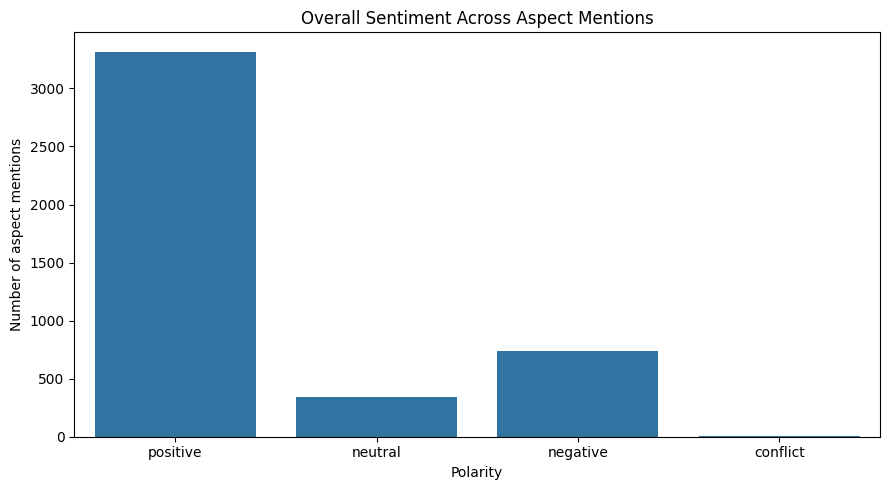

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=overall_sentiment,
    x="polarity",
    y="mentions",
    order=polarity_order
)

plt.title("Overall Sentiment Across Aspect Mentions")
plt.xlabel("Polarity")
plt.ylabel("Number of aspect mentions")
plt.tight_layout()
plt.show()

The distribution of sentiment labels also appears well-balanced with respect to the original review ratings. As expected, positive aspect sentiments dominate the dataset, reflecting the fact that most customers gave high star ratings.

However, it is also useful to examine the average number of aspect segments extracted from each review. This provides a rough estimate of the model's behavior and helps verify that it is consistently identifying multiple aspects where appropriate, rather than under- or over-segmenting the reviews.

In [29]:
stars_polarity = pd.crosstab(
    analysis_df["stars"],
    analysis_df["resolved_polarity"],
    normalize="index"
).mul(100)

for polarity in polarity_order:
    if polarity not in stars_polarity.columns:
        stars_polarity[polarity] = 0

stars_polarity = stars_polarity[polarity_order]

display(stars_polarity.round(1))

resolved_polarity,positive,neutral,negative,conflict
stars,,,,
1.0,1.0,6.7,92.3,0.0
2.0,12.0,15.3,72.5,0.2
3.0,50.4,20.8,28.5,0.3
4.0,95.8,3.0,1.2,0.1
5.0,99.7,0.1,0.2,0.0


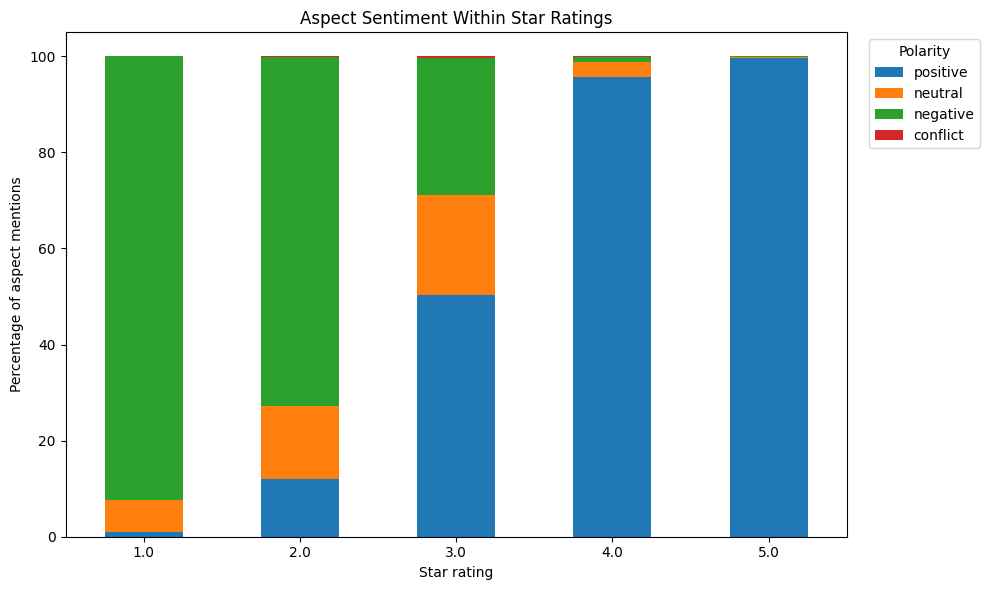

In [30]:
stars_polarity.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Aspect Sentiment Within Star Ratings")
plt.xlabel("Star rating")
plt.ylabel("Percentage of aspect mentions")
plt.xticks(rotation=0)
plt.legend(
    title="Polarity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

The sentiment distribution across different star ratings is particularly interesting because it closely matches the expected relationship between customer ratings and review content.

For **1-star reviews**, approximately **92%** of all extracted aspects are classified as **negative**, indicating that the model correctly identifies overwhelmingly negative customer experiences.

As the star rating increases, the proportion of negative aspects decreases substantially. In **2-star reviews**, the share of negative aspects drops by around **20 percentage points**. By **3 stars**, negative sentiment has fallen by approximately **64%** compared with 1-star reviews, reflecting the more balanced nature of these reviews. Finally, in **4-star reviews**, only **1.2%** of the extracted aspects are negative.

This consistent trend suggests that the ABSA model captures sentiment in a way that aligns well with customers' overall ratings, providing additional confidence that the extracted aspect-level predictions are meaningful and reliable.

## LLM Assistance Analysis

It is also useful to examine how often the ABSA pipeline relied on the LLM to make a prediction.

In [33]:
analysis_df["llm_called_clean"] = (
    analysis_df["llm_called"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "1": True,
        "yes": True,
        "false": False,
        "0": False,
        "no": False
    })
    .fillna(False)
)

llm_usage = (
    analysis_df["llm_called_clean"]
    .value_counts()
    .rename(index={True: "LLM called", False: "ABSA only"})
    .reset_index()
)

llm_usage.columns = ["method", "mentions"]

llm_usage["percentage"] = (
    llm_usage["mentions"]
    / llm_usage["mentions"].sum()
    * 100
).round(1)

display(llm_usage)



,method,mentions,percentage
0,ABSA only,3707,84.1
1,LLM called,699,15.9


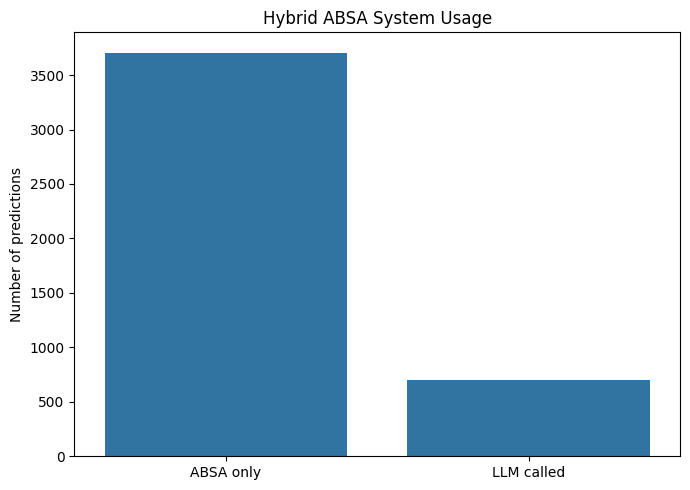

In [34]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=llm_usage,
    x="method",
    y="mentions"
)

plt.title("Hybrid ABSA System Usage")
plt.xlabel("")
plt.ylabel("Number of predictions")
plt.tight_layout()
plt.show()

Out of all aspect-level predictions, the model delegated **669 cases** to the LLM, representing approximately **16%** of the dataset. In the remaining **84%** of cases, the primary ABSA model was sufficiently confident to make predictions independently.

This result indicates that the confidence-based routing mechanism worked as intended. The LLM was only used for more challenging or uncertain cases, allowing the pipeline to maintain high efficiency while benefiting from the LLM's reasoning capabilities when additional support was needed.

# Identifying the Restaurant's Key Problems

Having verified the quality of the data and the reliability of the model's predictions, we can now move on to the main objective of this analysis: identifying the restaurant's key operational issues.

Using aspect-level sentiment extracted from customer reviews, we can determine which topics generate the most negative feedback, measure how frequently they occur, and uncover recurring patterns in customer complaints. These insights can help restaurant managers prioritize improvements and focus on the areas that are likely to have the greatest impact on customer satisfaction.

In [35]:
aspect_polarity_counts = pd.crosstab(
    analysis_df["resolved_aspect"],
    analysis_df["resolved_polarity"]
)

for polarity in polarity_order:
    if polarity not in aspect_polarity_counts.columns:
        aspect_polarity_counts[polarity] = 0

aspect_polarity_counts = aspect_polarity_counts[polarity_order]

aspect_polarity_counts["total_mentions"] = (
    aspect_polarity_counts[polarity_order].sum(axis=1)
)

aspect_polarity_counts = aspect_polarity_counts.sort_values(
    "total_mentions",
    ascending=False
)

display(aspect_polarity_counts.head(20))

resolved_polarity,positive,neutral,negative,conflict,total_mentions
resolved_aspect,,,,,
food,98,9,31,3,141
brunch,86,7,6,0,99
service,65,3,26,1,95
place,69,7,12,0,88
farmicia,55,3,11,0,69
menu,53,5,6,0,64
restaurant,32,5,16,0,53
table,26,6,16,0,48
meal,33,5,10,0,48


## Most Frequently Mentioned Restaurant Aspects

The first step is to identify which aspects customers discuss most often. The number of mentions provides an indication of what guests pay the most attention to during their dining experience.

The results show that **food** is by far the most frequently discussed aspect, with **141 mentions**, followed by **brunch (99)**, **service (95)**, and **place (88)**. This suggests that customers primarily evaluate the restaurant based on the quality of its food, brunch offerings, service, and overall environment.

## Restaurant Strengths

Next, we examine the aspects with the highest proportion of positive sentiment to identify the restaurant's key strengths.

Several aspects stand out with consistently high positive sentiment:

- **Atmosphere:** 32 positive mentions out of 36 (≈89%)
- **Brunch:** 86 out of 99 (≈87%)
- **Menu:** 53 out of 64 (≈83%)
- **Dinner:** 36 out of 45 (≈80%)
- **Place:** 69 out of 88 (≈78%)

These results suggest that guests particularly appreciate the restaurant's atmosphere, brunch experience, menu selection, dinner offerings, and overall location or interior. Maintaining these strengths is important, as they represent the restaurant's strongest competitive advantages according to customer feedback.

## Sentiment Distribution by Aspect

Looking at the sentiment distribution in percentage terms provides a clearer picture of the restaurant's strengths and weaknesses.

The strongest-performing aspects are **cocktails (92.9% positive)**, **atmosphere (88.9%)**, **brunch (86.9%)**, **friends (85.2%)**, and **menu (82.8%)**. These consistently receive positive feedback, indicating that they contribute significantly to customer satisfaction.

Several aspects receive a more mixed response. For example, **food** is discussed most frequently and receives **69.5% positive** sentiment, but it also accounts for **22.0% negative** mentions, suggesting there is still room for improvement. Similarly, **service** receives **68.4% positive** sentiment but also **27.4% negative**, making it one of the restaurant's most common sources of customer complaints.

The weakest-performing aspects are **reservation**, with only **38.5% positive** and **46.2% negative** sentiment, followed by **server (41.0% negative)**, **price (36.0% negative)**, and **table (33.3% negative)**. These categories represent the restaurant's primary pain points and should be prioritized for operational improvements.

In [36]:
aspect_polarity_pct = (
    aspect_polarity_counts[polarity_order]
    .div(aspect_polarity_counts["total_mentions"], axis=0)
    .mul(100)
    .round(1)
)

aspect_polarity_pct["total_mentions"] = (
    aspect_polarity_counts["total_mentions"]
)

display(aspect_polarity_pct.head(20))

resolved_polarity,positive,neutral,negative,conflict,total_mentions
resolved_aspect,,,,,
food,69.5,6.4,22.0,2.1,141
brunch,86.9,7.1,6.1,0.0,99
service,68.4,3.2,27.4,1.1,95
place,78.4,8.0,13.6,0.0,88
farmicia,79.7,4.3,15.9,0.0,69
menu,82.8,7.8,9.4,0.0,64
restaurant,60.4,9.4,30.2,0.0,53
table,54.2,12.5,33.3,0.0,48
meal,68.8,10.4,20.8,0.0,48


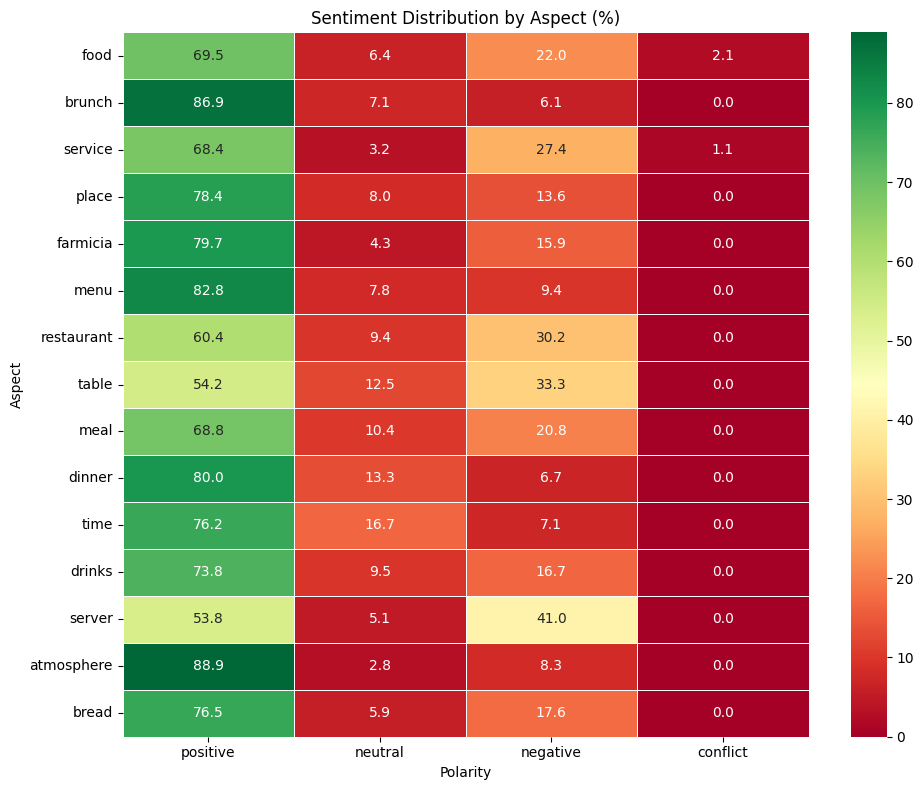

In [38]:
MIN_MENTIONS = 5

heatmap_data = aspect_polarity_pct[
    aspect_polarity_pct["total_mentions"] >= MIN_MENTIONS
].copy()

heatmap_data = heatmap_data.head(15)

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data[polarity_order],
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Sentiment Distribution by Aspect (%)")
plt.xlabel("Polarity")
plt.ylabel("Aspect")
plt.tight_layout()
plt.show()

In [45]:
problem_aspects = aspect_polarity_pct.reset_index()

problem_aspects["negative_rate"] = problem_aspects["negative"]
problem_aspects["negative_mentions"] = problem_aspects["resolved_aspect"].map(
    aspect_polarity_counts["negative"]
)

problem_aspects["problem_score"] = (
    problem_aspects["negative_rate"] *
    np.sqrt(problem_aspects["total_mentions"])
)

problem_aspects.sort_values("problem_score", ascending=False)

resolved_polarity,resolved_aspect,positive,neutral,negative,conflict,total_mentions,negative_rate,negative_mentions,problem_score
2,service,68.4,3.2,27.4,1.1,95,27.4,26,267.062165
0,food,69.5,6.4,22.0,2.1,141,22.0,31,261.235526
12,server,53.8,5.1,41.0,0.0,39,41.0,16,256.044918
17,reservation,38.5,15.4,46.2,0.0,26,46.2,12,235.574702
7,table,54.2,12.5,33.3,0.0,48,33.3,16,230.709168
...,...,...,...,...,...,...,...,...,...
664,baseline,100.0,0.0,0.0,0.0,1,0.0,0,0.000000
662,bay window seating,100.0,0.0,0.0,0.0,1,0.0,0,0.000000
661,bay window seats,100.0,0.0,0.0,0.0,1,0.0,0,0.000000
660,bc,100.0,0.0,0.0,0.0,1,0.0,0,0.000000


## Ranking the Restaurant's Key Problems

To prioritize the restaurant's most important issues, an integrated **Problem Score** was calculated. This metric combines both the **percentage of negative sentiment** and the **frequency with which an aspect is mentioned**.

The score is defined as:

\[
\text{Problem Score} = \text{Negative Rate} \times \sqrt{\text{Total Mentions}}
\]

Using the square root of the total number of mentions prevents aspects with only a few reviews from being ranked too highly while still giving greater importance to issues that affect a large number of customers.

Based on this metric, the restaurant's highest-priority problems are:

| Rank | Aspect | Problem Score | Interpretation |
|------:|---------|--------------:|----------------|
| 1 | **Service** | 267.1 | Frequently mentioned and consistently criticized. |
| 2 | **Food** | 261.2 | The most discussed aspect overall, with a substantial number of negative comments. |
| 3 | **Server** | 256.0 | Individual staff interactions generate a high proportion of complaints. |
| 4 | **Reservation** | 235.6 | Although mentioned less often, nearly half of the comments are negative. |
| 5 | **Table** | 230.7 | Table-related issues occur often enough to become a significant customer concern. |

This ranking provides a practical way to prioritize operational improvements. Rather than focusing only on the highest negative percentage or only on the most frequently mentioned aspects, the **Problem Score** balances both factors, highlighting issues that have the greatest overall impact on the customer experience.

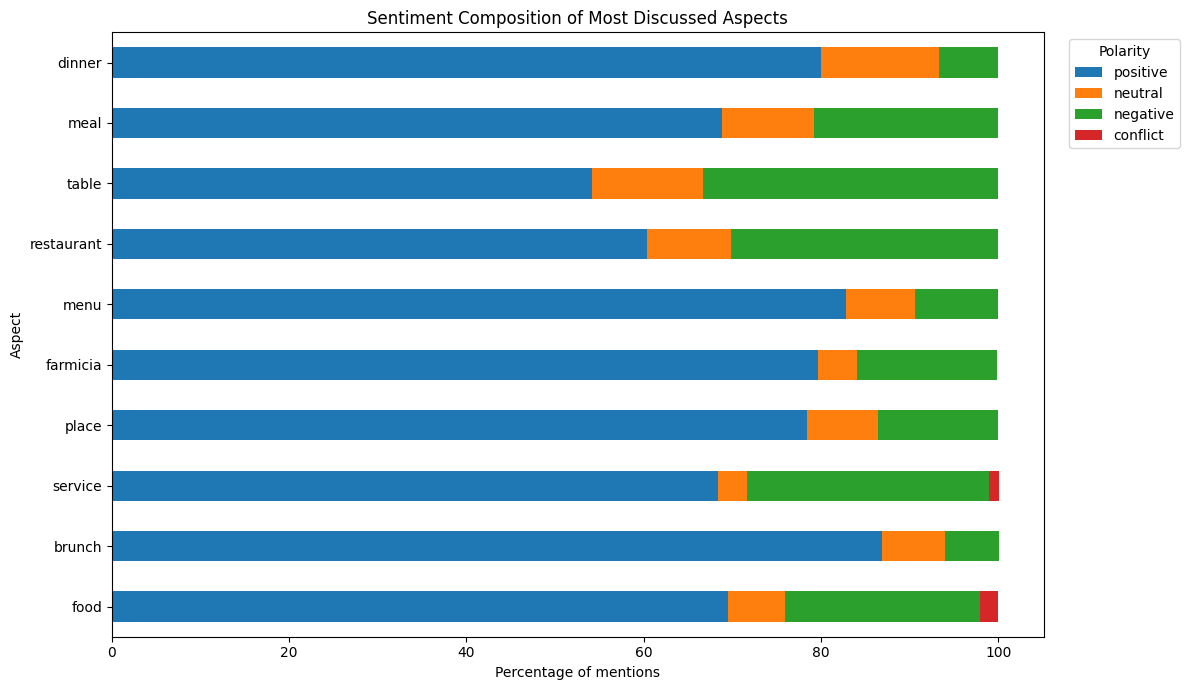

In [46]:
top_aspects = (
    aspect_polarity_counts
    .head(10)
    .index
)

stacked_data = aspect_polarity_pct.loc[
    top_aspects,
    polarity_order
]

stacked_data.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Sentiment Composition of Most Discussed Aspects")
plt.xlabel("Percentage of mentions")
plt.ylabel("Aspect")
plt.legend(
    title="Polarity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [48]:
review_polarities = (
    analysis_df.groupby("id")["resolved_polarity"]
    .agg(lambda values: sorted(set(values)))
    .reset_index(name="polarities")
)

review_polarities["number_of_polarities"] = (
    review_polarities["polarities"].apply(len)
)

mixed_review_ids = review_polarities.loc[
    review_polarities["number_of_polarities"] >= 2,
    "id"
]

mixed_reviews = analysis_df[
    analysis_df["id"].isin(mixed_review_ids)
].copy()

print("Mixed reviews:", mixed_reviews["id"].nunique())

Mixed reviews: 68


In [49]:
mixed_review_examples = (
    mixed_reviews.groupby(["id", "text"])
    .apply(
        lambda group: list(
            zip(
                group["resolved_aspect"],
                group["resolved_polarity"]
            )
        ),
        include_groups=False
    )
    .reset_index(name="aspect_sentiments")
)

display(mixed_review_examples.head(10))

,id,text,aspect_sentiments
0,5,We came here for Sunday brunch around 1 and we...,"[(waiting time, positive), (service, positive)..."
1,8,Went for dinner. Environment was nice with a ...,"[(dinner, neutral), (environment, positive), (..."
2,16,I visited for breakfast at 10:30 on a Sunday m...,"[(breakfast, positive), (sightseeing, neutral)..."
3,18,I made a reservation a week in advance. I arri...,"[(reservation, negative), (reservation, neutra..."
4,19,We went for a work lunch at 12:45pm and made r...,"[(work lunch, neutral), (12:45pm, neutral), (r..."
5,24,"Well presented food, but underwhelming. The cr...","[(food, negative), (crab cakes, negative), (so..."
6,28,Had brunch here on a Saturday morning prior to...,"[(brunch, neutral), (saturday morning, neutral..."
7,29,I really wanted to like Farmicia. Who wouldn't...,"[(farmicia, negative), (farm-to-table dishes, ..."
8,31,I ate at Farmicia for the first time this morn...,"[(restaurant, negative), (waiting time, neutra..."
9,34,You know how people come to Philly from out of...,"[(people, positive), (philly, positive), (town..."


## Mixed-Sentiment Reviews

One of the key advantages of Aspect-Based Sentiment Analysis (ABSA) is its ability to identify different sentiments within the same review. Unlike traditional sentiment analysis, which assigns a single label to the entire review, ABSA evaluates each mentioned aspect independently.

To measure how often this occurs, we identified reviews containing **two or more distinct sentiment categories** (e.g., both positive and negative aspects).

The analysis found **68 mixed-sentiment reviews** out of **200 total reviews**, meaning that approximately **34%** of all customer reviews contain both positive and negative opinions.

This result highlights the importance of aspect-level analysis. Many customers do not simply describe their experience as entirely positive or entirely negative. Instead, they may praise one part of their visit—for example, the food or atmosphere—while criticizing another, such as the service or reservation process.

Without ABSA, these nuanced insights would be lost, as a conventional sentiment classifier would assign only a single overall sentiment label to each review. By analyzing sentiment at the aspect level, businesses can identify the specific strengths and weaknesses mentioned within the same customer experience, leading to more targeted and actionable recommendations.

In [53]:
high_rating_negative_mentions = analysis_df[
    (analysis_df["stars"] >= 4)
    & (analysis_df["resolved_polarity"] == "negative")
]

print(
    "Negative aspect mentions inside 4–5 star reviews:",
    len(high_rating_negative_mentions)
)

display(
    high_rating_negative_mentions[
        [
            "stars",
            "text",
            "resolved_aspect",
            "resolved_polarity"
        ]
    ].head(10)
)

Negative aspect mentions inside 4–5 star reviews: 23


,stars,text,resolved_aspect,resolved_polarity
766,4.0,You know how people come to Philly from out of...,potatoes,negative
767,4.0,You know how people come to Philly from out of...,bread,negative
769,4.0,You know how people come to Philly from out of...,bread,negative
772,4.0,You know how people come to Philly from out of...,bread,negative
779,4.0,You know how people come to Philly from out of...,dinner,negative
1078,5.0,mandy was exquisite ! her personality was bett...,server,negative
1333,4.0,"Happy hour and two more Cobb salads, very good...",dining room,negative
1341,4.0,got nachos and the tostitos and guac for lunch...,bread,negative
1496,5.0,Came with a group of 14 for work lunch and we ...,toasted sourdough,negative
2017,4.0,I came here for brunch and got the goat cheese...,eggs benny,negative


## Negative Aspects in Highly Rated Reviews

An additional analysis revealed that negative aspect-level sentiment is present even in reviews with **4- and 5-star overall ratings**. This indicates that a high overall customer rating does not necessarily mean that every part of the dining experience was satisfactory.

Among these highly rated reviews, the most common negative mentions were related to specific menu items (such as **bread** and **potatoes**), interactions with **servers**, and certain elements of the overall dining experience.

This finding further demonstrates the value of Aspect-Based Sentiment Analysis. While a traditional review rating suggests that customers were generally satisfied, aspect-level analysis uncovers localized issues that would otherwise remain hidden. As a result, businesses can identify and address specific weaknesses without relying solely on overall star ratings.

In [54]:
business_summary = aspect_polarity_counts.reset_index()

business_summary["positive_rate"] = (
    business_summary["positive"]
    / business_summary["total_mentions"]
    * 100
).round(1)

business_summary["negative_rate"] = (
    business_summary["negative"]
    / business_summary["total_mentions"]
    * 100
).round(1)

business_summary["neutral_rate"] = (
    business_summary["neutral"]
    / business_summary["total_mentions"]
    * 100
).round(1)

business_summary["priority_score"] = (
    business_summary["negative"]
    * business_summary["negative_rate"]
    / 100
).round(2)

business_summary = business_summary.sort_values(
    "priority_score",
    ascending=False
)

display(business_summary.head(20))

resolved_polarity,resolved_aspect,positive,neutral,negative,conflict,total_mentions,positive_rate,negative_rate,neutral_rate,priority_score
2,service,65,3,26,1,95,68.4,27.4,3.2,7.12
0,food,98,9,31,3,141,69.5,22.0,6.4,6.82
12,server,21,2,16,0,39,53.8,41.0,5.1,6.56
17,reservation,10,4,12,0,26,38.5,46.2,15.4,5.54
7,table,26,6,16,0,48,54.2,33.3,12.5,5.33
6,restaurant,32,5,16,0,53,60.4,30.2,9.4,4.83
213,butternut squash risotto balls,0,0,4,0,4,0.0,100.0,0.0,4.00
188,bread options,0,0,4,0,4,0.0,100.0,0.0,4.00
24,waiter,11,1,9,0,21,52.4,42.9,4.8,3.86
113,hostess,1,1,5,0,7,14.3,71.4,14.3,3.57


## Summary of Key Problem Areas

Ranking aspects using the integrated **Problem Score** revealed that the restaurant's highest-priority issues are **service**, **food quality**, **server performance**, **reservation management**, and **table allocation**.

These aspects combine a relatively high proportion of negative sentiment with a substantial number of customer mentions, making them the areas with the greatest overall impact on the dining experience. Consequently, they should be considered the highest priorities for operational improvements, as addressing these issues is likely to produce the greatest increase in overall customer satisfaction.

### Grouping Aspect Terms

The next challenge is grouping aspect terms into meaningful business topics. The dataset contains **more than 1,500 unique aspect terms**, many of which refer to the same concept using different words or levels of specificity. For example, customers may mention *bread*, *steak*, *crab cakes*, or *potatoes*, even though all of these belong to the broader category of **food**.

An initial attempt was made to cluster aspect terms using sentence embeddings. However, the results were not sufficiently accurate, as semantically similar terms were not always grouped correctly, while unrelated terms were occasionally assigned to the same cluster.

This highlights one of the limitations of fully unsupervised clustering for aspect normalization. In practice, grouping aspect terms into meaningful business categories often requires additional domain knowledge, hierarchical rules, or manual validation to produce reliable and interpretable topics.